In [17]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score 
from sklearn.metrics import ConfusionMatrixDisplay 


In [2]:
matches = pd.read_csv('../data/processed/features_basic.csv')

In [3]:
matches['GoalDiffLast5'] = matches['HomeGoalsLast5'] - matches['AwayGoalsLast5'] 
matches['PointsDiffLast5'] = matches['HomePointsLast5'] - matches['AwayPointsLast5'] 
matches['GoalAgainstDiffLast5'] = matches['AwayGoalsAgainstLast5'] - matches['HomeGoalsAgainstLast5'] 
matches['ShotDiffLast5'] = matches['HomeShotsForLast5'] - matches['AwayShotsForLast5'] 
matches['ShotOTDiffLast5'] = matches['HomeShotsOnTargetLast5'] - matches['AwayShotsOnTargetLast5']

C:\Users\harry\AppData\Local\Temp\ipykernel_4504\2143085457.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matches['GoalDiffLast5'] = matches['HomeGoalsLast5'] - matches['AwayGoalsLast5']
C:\Users\harry\AppData\Local\Temp\ipykernel_4504\2143085457.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matches['PointsDiffLast5'] = matches['HomePointsLast5'] - matches['AwayPointsLast5']
C:\Users\harry\AppData\Local\Temp\ipykernel_4504\2143085457.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resul

In [ ]:
matches[
    [
        "HomeTeam",
        "AwayTeam",
        "MatchDateTime",
        "GoalDiffLast5",
        "PointsDiffLast5",
        "GoalAgainstDiffLast5",
        "ShotDiffLast5",
        "ShotOTDiffLast5",
        "HomeGoalsLast5",
        "AwayGoalsLast5",
        "HomePointsLast5",
        "AwayPointsLast5",
        "HomeGoalsAgainstLast5",
        "AwayGoalsAgainstLast5",
        "HomeShotsForLast5",
        "HomeShotsOnTargetLast5",
        "HomeShotsAgainstLast5",
        "HomeShotsOnTargetAgainstLast5",
        "AwayShotsForLast5",
        "AwayShotsOnTargetLast5",
        "AwayShotsAgainstLast5",
        "AwayShotsOnTargetAgainstLast5"
    ]
][800:820]

,HomeTeam,AwayTeam,MatchDateTime,GoalDiffLast5,PointsDiffLast5,GoalAgainstDiffLast5,ShotDiffLast5,ShotOTDiffLast5,HomeGoalsLast5,AwayGoalsLast5,...,HomeGoalsAgainstLast5,AwayGoalsAgainstLast5,HomeShotsForLast5,HomeShotsOnTargetLast5,HomeShotsAgainstLast5,HomeShotsOnTargetAgainstLast5,AwayShotsForLast5,AwayShotsOnTargetLast5,AwayShotsAgainstLast5,AwayShotsOnTargetAgainstLast5
800,West Ham,Man City,2023-09-16 15:00:00,-0.200000,-2,-0.60,-4.00,-2.200000,2.0,2.200000,...,1.2,0.60,13.00,3.60,17.0,4.80,17.0,5.800000,7.200000,2.400000
801,Tottenham,Sheffield United,2023-09-16 15:00:00,2.000000,12,0.75,8.10,3.500000,3.0,1.000000,...,1.0,1.75,16.60,7.00,15.8,4.20,8.5,3.500000,21.500000,6.750000
802,Man United,Brighton,2023-09-16 15:00:00,-1.200000,0,0.00,-1.00,-2.400000,1.4,2.600000,...,1.6,1.60,17.20,5.60,15.2,4.80,18.2,8.000000,11.600000,3.600000
803,Fulham,Luton,2023-09-16 15:00:00,0.333333,4,0.60,-3.40,1.133333,1.0,0.666667,...,2.4,3.00,8.60,2.80,16.6,8.20,12.0,1.666667,18.333333,7.666667
804,Aston Villa,Crystal Palace,2023-09-16 15:00:00,0.800000,1,-1.00,-3.80,-0.600000,2.0,1.200000,...,2.0,1.00,13.20,5.40,12.0,5.00,17.0,6.000000,10.600000,2.600000
805,Newcastle,Brentford,2023-09-16 17:30:00,-0.200000,-5,-0.60,-0.60,0.400000,1.6,1.800000,...,1.6,1.00,13.80,5.60,15.2,5.00,14.4,5.200000,14.400000,4.200000
806,Bournemouth,Chelsea,2023-09-17 14:00:00,-0.400000,-3,-0.60,-6.40,-0.600000,0.8,1.200000,...,1.8,1.20,11.40,4.00,18.6,6.40,17.8,4.600000,11.200000,3.000000
807,Everton,Arsenal,2023-09-17 16:30:00,-2.000000,-9,-0.80,-1.40,-0.800000,0.6,2.600000,...,1.6,0.80,14.40,6.00,10.6,4.20,15.8,6.800000,8.800000,1.800000
808,Nott'm Forest,Burnley,2023-09-18 19:45:00,0.400000,6,1.40,-1.60,0.000000,1.4,1.000000,...,1.4,2.80,9.00,3.40,15.4,5.00,10.6,3.400000,16.600000,7.800000
809,Crystal Palace,Fulham,2023-09-23 15:00:00,0.200000,0,0.60,5.80,3.200000,1.2,1.000000,...,1.4,2.00,15.00,5.80,12.4,2.80,9.2,2.600000,13.800000,7.000000


In [8]:
features = [ 'GoalDiffLast5', 'PointsDiffLast5', 'GoalAgainstDiffLast5', 'ShotDiffLast5', 'ShotOTDiffLast5' ]
train = matches[matches['Season'] != '25-26'] 
test = matches[matches['Season'] == '25-26']

In [9]:
X_train = train[features] 
y_train = train['FTR'] 
X_test = test[features] 
y_test = test['FTR']

In [35]:
 
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [36]:
preds = model.predict(X_test)

In [37]:
accuracy = accuracy_score(y_test, preds) 
print(accuracy)

0.40789473684210525


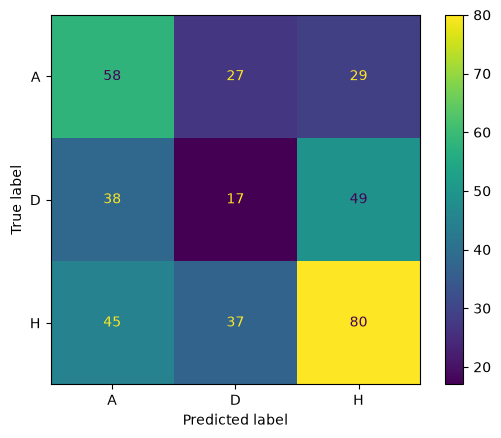

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test, preds)

In [20]:
probs = model.predict_proba(X_test) 
print(model.classes_) 
print(probs[0])

['A' 'D' 'H']
[0.2239788  0.22834765 0.54767355]


In [21]:
results = test[['HomeTeam', 'AwayTeam', 'FTR']].copy() 
results['Predicted'] = preds 
results['AwayProb'] = probs[:, 0] 
results['DrawProb'] = probs[:, 1] 
results['HomeProb'] = probs[:, 2] 
results.head(10)

,HomeTeam,AwayTeam,FTR,Predicted,AwayProb,DrawProb,HomeProb
1520,Liverpool,Bournemouth,H,H,0.223979,0.228348,0.547674
1521,Aston Villa,Newcastle,D,A,0.444930,0.283428,0.271642
1522,Brighton,Fulham,D,H,0.202556,0.230950,0.566493
1523,Sunderland,West Ham,H,A,0.548077,0.222147,0.229776
1524,Tottenham,Burnley,H,A,0.572577,0.260954,0.166470
1525,Wolves,Man City,A,A,0.483451,0.238488,0.278061
1526,Chelsea,Crystal Palace,D,A,0.391077,0.267726,0.341197
1527,Nott'm Forest,Brentford,H,A,0.382720,0.237251,0.380029
1528,Man United,Arsenal,A,H,0.309859,0.233396,0.456745
1529,Leeds,Everton,H,A,0.475835,0.262824,0.261341


In [22]:
importance = pd.Series( model.coef_[2], index=features ).sort_values(ascending=False) 
print(importance)

GoalAgainstDiffLast5    0.226686
GoalDiffLast5           0.103645
ShotOTDiffLast5         0.060258
ShotDiffLast5           0.044182
PointsDiffLast5        -0.002377
dtype: float64


In [23]:
baseline = ['H'] * len(y_test)

accuracy_score(y_test, baseline)

0.4263157894736842

In [24]:
y_train.value_counts(normalize=True)

FTR
H    0.445395
A    0.324342
D    0.230263
Name: proportion, dtype: float64

In [25]:
y_test.value_counts(normalize=True)

FTR
H    0.426316
A    0.300000
D    0.273684
Name: proportion, dtype: float64

In [26]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [39]:
results['Correct'] = results['Predicted'] == results['FTR'] 
results.sort_values('HomeProb', ascending=False).head(20)[[ 'HomeTeam', 'AwayTeam', 'FTR', 'Predicted', 'HomeProb', 'Correct' ]]

,HomeTeam,AwayTeam,FTR,Predicted,HomeProb,Correct
1705,Man United,Wolves,D,H,0.799364,False
1673,Arsenal,Wolves,H,H,0.799132,True
1531,Man City,Tottenham,A,H,0.765332,False
1879,Man City,Crystal Palace,H,H,0.759985,True
1695,Liverpool,Wolves,H,H,0.745969,True
1819,Liverpool,Tottenham,D,H,0.734213,False
1641,Man City,Leeds,H,H,0.707677,True
1891,Man City,Aston Villa,A,H,0.705006,False
1646,Aston Villa,Wolves,H,H,0.691960,True
1638,Arsenal,Tottenham,H,H,0.690103,True


In [40]:
results['HomeProbBin'] = pd.cut( results['HomeProb'], bins=[0, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0] ) 
calibration = results.groupby('HomeProbBin')['Correct'].agg(['mean', 'count']) 
print(calibration)

                 mean  count
HomeProbBin                 
(0.0, 0.4]   0.410959    146
(0.4, 0.5]   0.467290    107
(0.5, 0.6]   0.511905     84
(0.6, 0.7]   0.628571     35
(0.7, 0.8]   0.500000      8


In [41]:
from sklearn.metrics import log_loss 
print(log_loss(y_test, probs))

1.0500438280304538
